✅ فونت انتخاب‌شده: B Nazanin
✅ سرور Echo بر روی 127.0.0.1:1281 راه‌اندازی شد.
تعداد کل نمونه‌ها: 20000
زمان کل اجرا: 0.6801 ثانیه
پهنای باند مؤثر: 58811.53 بایت/ثانیه (معادل 0.470 Mbps)
میانگین RTT: 0.034 میلی‌ثانیه
انحراف معیار: 0.010 میلی‌ثانیه
حداقل RTT: 0.019 میلی‌ثانیه
حداکثر RTT: 0.343 میلی‌ثانیه

تعداد نمونه‌هایی با RTT <= 0.122 میلی‌ثانیه: 19978 عدد
درصد نمونه‌ها با RTT <= 0.122 میلی‌ثانیه: 99.89%


C:\Users\Asus\AppData\Local\Temp\ipykernel_27864\2976589243.py:128: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_27864\2976589243.py:128: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_27864\2976589243.py:128: UserWarning: Glyph 67 (C) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_27864\2976589243.py:128: UserWarning: Glyph 68 (D) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_27864\2976589243.py:128: UserWarning: Glyph 70 (F) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_27864\2976589243.py:128: UserWarning: Glyph 109 (m) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_27864\2976589243.py:128: UserWarning: Glyph 115 (s) missing from font(s)

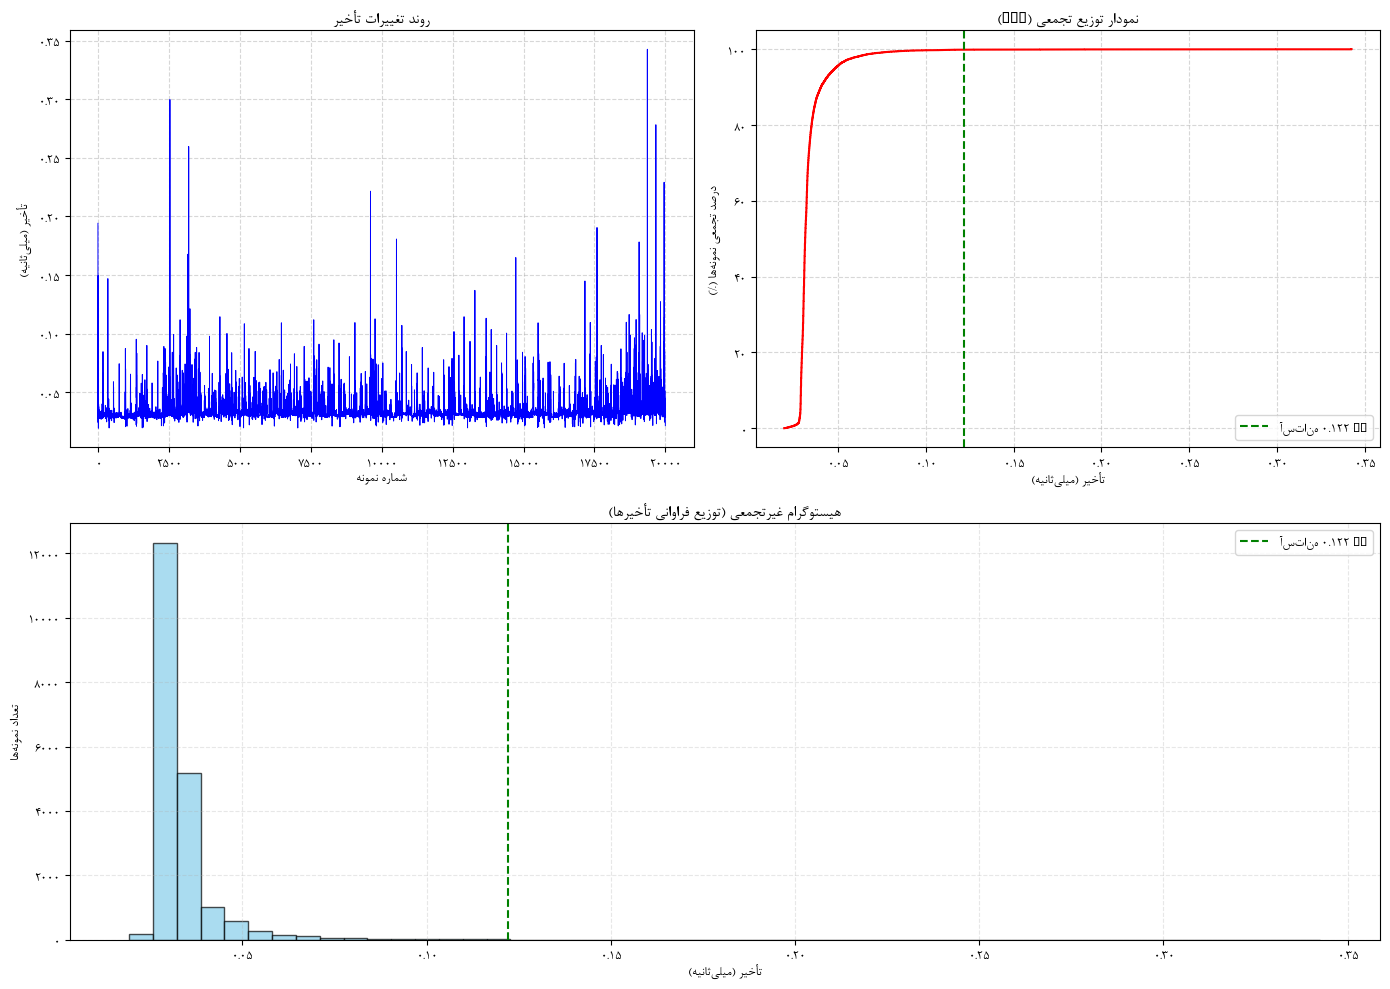

🛑 سرور متوقف شد.


In [5]:
import socket
import time
import threading
import socketserver
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import arabic_reshaper
from bidi.algorithm import get_display

# ========== توابع کمکی برای متن فارسی ==========
def fix_persian_text(text):
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)

def find_persian_font():
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    priority_fonts = ['Vazir', 'Sahel', 'B Nazanin', 'IRANSans', 'Tahoma', 'DejaVu Sans', 'Arial']
    for font in priority_fonts:
        for available in available_fonts:
            if font.lower() in available.lower():
                return available
    return 'sans-serif'

selected_font = find_persian_font()
plt.rcParams['font.family'] = selected_font
plt.rcParams['axes.unicode_minus'] = False
print(f"✅ فونت انتخاب‌شده: {selected_font}")

# ========== تعریف سرور Echo ==========
class EchoHandler(socketserver.StreamRequestHandler):
    def handle(self):
        while True:
            data = self.rfile.read(1)
            if not data:
                break
            self.wfile.write(data)

class ThreadedTCPServer(socketserver.ThreadingMixIn, socketserver.TCPServer):
    allow_reuse_address = True
    daemon_threads = True

# ========== تنظیمات تست ==========
HOST = '127.0.0.1'
PORT = 0          # سیستم یک پورت خالی انتخاب می‌کند
COUNT = 20000

def run_client(port):
    """کد کلاینت با پورت مشخص"""
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.setsockopt(socket.IPPROTO_TCP, socket.TCP_NODELAY, 1)
    sock.settimeout(2)
    sock.connect((HOST, port))

    msg = b'A'
    rtt_list = []

    start_time = time.perf_counter()
    for _ in range(COUNT):
        t1 = time.perf_counter()
        sock.sendall(msg)
        data = sock.recv(1)
        while len(data) < 1:
            data += sock.recv(1 - len(data))
        t2 = time.perf_counter()
        rtt_list.append(t2 - t1)
    end_time = time.perf_counter()
    sock.close()

    rtt_ms = np.array(rtt_list) * 1000
    total_time = end_time - start_time
    total_bytes = COUNT * 2
    throughput = total_bytes / total_time

    avg_rtt = np.mean(rtt_ms)
    min_rtt = np.min(rtt_ms)
    max_rtt = np.max(rtt_ms)
    std_rtt = np.std(rtt_ms)

    threshold = 0.122
    count_below_threshold = np.sum(rtt_ms <= threshold)
    percent_below_threshold = (count_below_threshold / COUNT) * 100

    print(f"تعداد کل نمونه‌ها: {COUNT}")
    print(f"زمان کل اجرا: {total_time:.4f} ثانیه")
    print(f"پهنای باند مؤثر: {throughput:.2f} بایت/ثانیه (معادل {throughput*8/1e6:.3f} Mbps)")
    print(f"میانگین RTT: {avg_rtt:.3f} میلی‌ثانیه")
    print(f"انحراف معیار: {std_rtt:.3f} میلی‌ثانیه")
    print(f"حداقل RTT: {min_rtt:.3f} میلی‌ثانیه")
    print(f"حداکثر RTT: {max_rtt:.3f} میلی‌ثانیه")
    print(f"\nتعداد نمونه‌هایی با RTT <= {threshold} میلی‌ثانیه: {count_below_threshold} عدد")
    print(f"درصد نمونه‌ها با RTT <= {threshold} میلی‌ثانیه: {percent_below_threshold:.2f}%")

    # ========== رسم نمودارها ==========
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

    # نمودار ۱: سری زمانی
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(rtt_ms, 'b-', linewidth=0.7)
    ax1.set_xlabel(fix_persian_text('شماره نمونه'))
    ax1.set_ylabel(fix_persian_text('تأخیر (میلی‌ثانیه)'))
    ax1.set_title(fix_persian_text('روند تغییرات تأخیر'))
    ax1.grid(True, linestyle='--', alpha=0.5)

    # نمودار ۲: CDF تجمعی
    ax2 = fig.add_subplot(gs[0, 1])
    sorted_rtt = np.sort(rtt_ms)
    cdf = np.arange(1, len(sorted_rtt) + 1) / len(sorted_rtt) * 100
    ax2.step(sorted_rtt, cdf, where='post', color='red', linewidth=1.5)
    ax2.axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'آستانه {threshold} ms')
    ax2.set_xlabel(fix_persian_text('تأخیر (میلی‌ثانیه)'))
    ax2.set_ylabel(fix_persian_text('درصد تجمعی نمونه‌ها (%)'))
    ax2.set_title(fix_persian_text('نمودار توزیع تجمعی (CDF)'))
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.5)

    # نمودار ۳: هیستوگرام غیرتجمعی
    ax3 = fig.add_subplot(gs[1, :])
    ax3.hist(rtt_ms, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    ax3.axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'آستانه {threshold} ms')
    ax3.set_xlabel(fix_persian_text('تأخیر (میلی‌ثانیه)'))
    ax3.set_ylabel(fix_persian_text('تعداد نمونه‌ها'))
    ax3.set_title(fix_persian_text('هیستوگرام غیرتجمعی (توزیع فراوانی تأخیرها)'))
    ax3.legend()
    ax3.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

def main():
    # راه‌اندازی سرور با پورت 0 (سیستم یک پورت خالی انتخاب می‌کند)
    server = ThreadedTCPServer((HOST, PORT), EchoHandler)
    actual_port = server.server_address[1]
    print(f"✅ سرور Echo بر روی {HOST}:{actual_port} راه‌اندازی شد.")

    server_thread = threading.Thread(target=server.serve_forever)
    server_thread.daemon = True
    server_thread.start()

    time.sleep(0.1)  # صبر برای آماده‌سازی سرور

    try:
        run_client(actual_port)
    finally:
        server.shutdown()
        server.server_close()
        print("🛑 سرور متوقف شد.")

if __name__ == "__main__":
    main()

In [ ]:
!pip install matplotlib

In [2]:
!pip install arabic_reshaper

In [4]:
!pip install arabic-reshaper
!pip install python-bidi